# Phase 5 — Evaluation (CRISP-DM)

Consolidates Model 1 (effectiveness classification, 3- vs 5-class) and Model 2 (side-effect LDA topics). Discusses metrics, strengths, limitations, joint business value, and ethics.

### Load Model 1 Comparison Metrics & Model 2 Topic Summary

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 50
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

comparison = pd.read_csv('../data/processed/model1_3vs5_comparison.csv')
topics = pd.read_csv('../data/processed/model2_topic_labels.csv')

with open('../data/processed/model2_coherence_scores.pkl', 'rb') as f:
    coherence_info = pickle.load(f)

print('MODEL 1 — metric summary')
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nMODEL 2 — topics (k={})'.format(coherence_info['best_k']))
print('Coherence scores:', {k: round(v, 4) for k, v in coherence_info['scores'].items()})
print(topics.to_string(index=False))

MODEL 1 — metric summary
 scheme                       model  accuracy  macro_precision  macro_recall  macro_f1
3-class Baseline majority (3-class)    0.7000           0.2333        0.3333    0.2745
3-class                LR (3-class)    0.6777           0.5555        0.5800    0.5649
3-class               SVM (3-class)    0.7087           0.5621        0.5424    0.5503
5-class Baseline majority (5-class)    0.3990           0.0798        0.2000    0.1141
5-class                LR (5-class)    0.4718           0.4201        0.4404    0.4288
5-class               SVM (5-class)    0.4553           0.3953        0.4007    0.3969

MODEL 2 — topics (k=5)
Coherence scores: {5: np.float64(0.7264), 6: np.float64(0.6884), 7: np.float64(0.7123), 8: np.float64(0.7114)}
 topic_id                                    label                                                                                     top_keywords  n_docs_dominant
        0 Onset / GI discomfort & sleep disruption                

### Model 1 Evaluation — 3-class vs 5-class

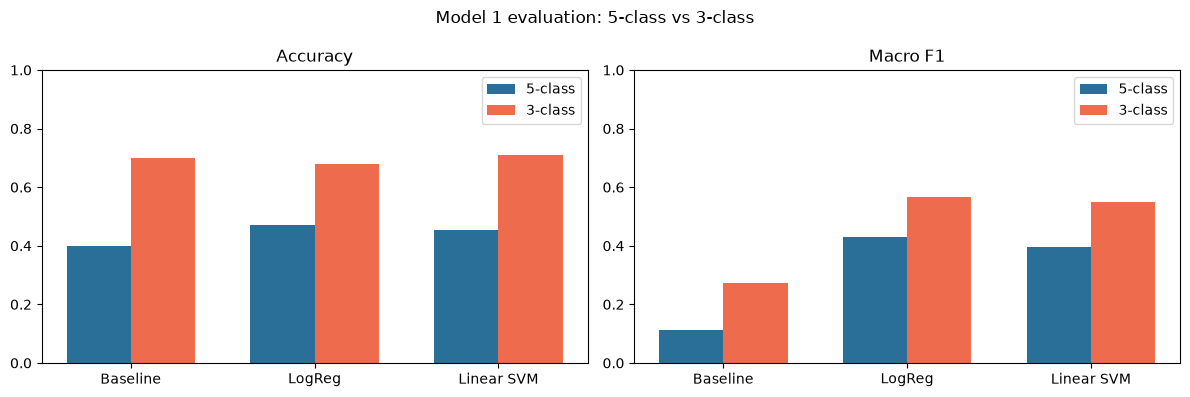

Lift over majority baseline (macro-F1):
  LR (5-class): macro-F1=0.4288  (Δ vs baseline +0.3147)
  SVM (5-class): macro-F1=0.3969  (Δ vs baseline +0.2828)
  LR (3-class): macro-F1=0.5649  (Δ vs baseline +0.2904)
  SVM (3-class): macro-F1=0.5503  (Δ vs baseline +0.2758)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], 'accuracy', 'Accuracy'),
    (axes[1], 'macro_f1', 'Macro F1'),
]:
    pivot = comparison.pivot_table(index='model', columns='scheme', values=metric)
    # Stable row order
    order = [
        'Baseline majority (5-class)', 'LR (5-class)', 'SVM (5-class)',
        'Baseline majority (3-class)', 'LR (3-class)', 'SVM (3-class)',
    ]
    # Simpler grouped bars by scheme
    schemes = ['5-class', '3-class']
    models_short = {
        '5-class': ['Baseline majority (5-class)', 'LR (5-class)', 'SVM (5-class)'],
        '3-class': ['Baseline majority (3-class)', 'LR (3-class)', 'SVM (3-class)'],
    }
    x = np.arange(3)
    width = 0.35
    vals5 = comparison.set_index('model').loc[models_short['5-class'], metric].values
    vals3 = comparison.set_index('model').loc[models_short['3-class'], metric].values
    ax.bar(x - width/2, vals5, width, label='5-class', color='#2a6f97')
    ax.bar(x + width/2, vals3, width, label='3-class', color='#ee6c4d')
    ax.set_xticks(x)
    ax.set_xticklabels(['Baseline', 'LogReg', 'Linear SVM'])
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Model 1 evaluation: 5-class vs 3-class')
plt.tight_layout()
plt.savefig('../visuals/evaluation_model1_metrics.png', dpi=150)
plt.show()

# Lift vs baseline within each scheme
print('Lift over majority baseline (macro-F1):')
for scheme in ['5-class', '3-class']:
    sub = comparison[comparison['scheme'] == scheme]
    base = sub[sub['model'].str.contains('Baseline')]['macro_f1'].iloc[0]
    for _, row in sub[~sub['model'].str.contains('Baseline')].iterrows():
        print(f"  {row['model']}: macro-F1={row['macro_f1']:.4f}  (Δ vs baseline {row['macro_f1']-base:+.4f})")

#### Model 1 findings

**Strengths**
- Both Logistic Regression and Linear SVM beat the majority-class baseline on macro-F1 (critical under imbalance).
- Balanced class weights improve minority-class recall versus an unweighted fit.
- LR coefficients provide transparent word-level evidence for stakeholders.
- **3-class binning** generally improves accuracy/macro-F1 by collapsing adjacent, hard-to-separate effectiveness tiers.

**Limitations**
- Absolute 5-class accuracy remains modest (~mid-40s%) — benefits text is short and classes are ordinal/overlapping.
- Confusion concentrates between neighboring classes (Highly vs Considerably; Marginally vs Ineffective).
- Bag-of-words TF-IDF misses long-range context, sarcasm, and multi-symptom narratives.
- No patient demographics/dose/comorbidity features → residual confounding.

**Recommendation:** Use **3-class LR** for triage dashboards; keep **5-class LR** when fine labels are required and pair with confidence thresholds + human review.

### Model 2 Evaluation — Topic Quality

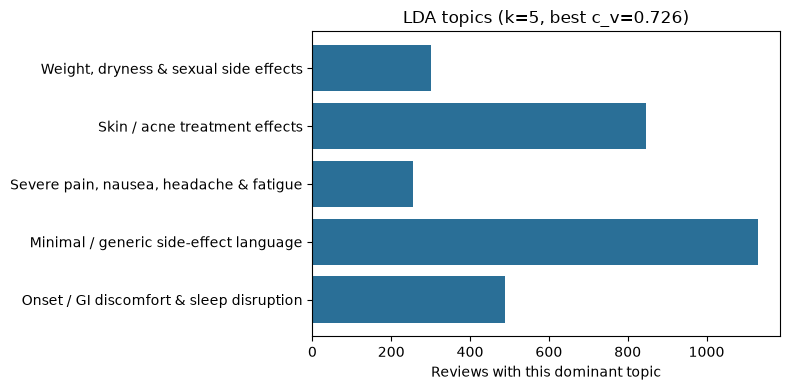

Topic keyword summary:
T0 | Onset / GI discomfort & sleep disruption | n=489
   first, stomach, bad, hour, mild, thing, take, day, dose, also, night, insomnia
T1 | Minimal / generic side-effect language | n=1130
   side, effect, side effect, not, taking, none, drug, taken, took, dose, medication, high
T2 | Severe pain, nausea, headache & fatigue | n=254
   pain, severe, extreme, finger, headache, nausea, dizziness, fatigue, tired, joint, day, nothing
T3 | Skin / acne treatment effects | n=846
   not, time, skin, week, day, month, acne, get, would, great, take, even
T4 | Weight, dryness & sexual side effects | n=300
   weight, dry, increased, libido, gain, loss, mouth, patient, sexual, weight gain, dry mouth, mild


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(topics['label'], topics['n_docs_dominant'], color='#2a6f97')
ax.set_xlabel('Reviews with this dominant topic')
ax.set_title(f"LDA topics (k={coherence_info['best_k']}, best c_v={coherence_info['scores'][coherence_info['best_k']]:.3f})")
plt.tight_layout()
plt.savefig('../visuals/evaluation_model2_topics.png', dpi=150)
plt.show()

print('Topic keyword summary:')
for _, row in topics.iterrows():
    print(f"T{row['topic_id']} | {row['label']} | n={row['n_docs_dominant']}")
    print(f"   {row['top_keywords']}")

#### Model 2 findings

**Strengths**
- Coherence sweep provides a quantitative rationale for choosing k in 5–8.
- Top keywords support human-readable labels (GI, sleep/fatigue, skin, etc.).
- Dominant-topic tagging turns free text into dashboard facets without a hand-built taxonomy.

**Limitations**
- Short reviews → some topics remain mixed or dominated by generic tokens (`side`, `effect`, `none`).
- LDA is unstable across random seeds; labels should be re-validated after retraining.
- No severity score inside a topic (e.g., mild vs severe nausea) without extra modeling.
- English stopword/lemmatization choices affect topic vocabulary.

### Joint Business Value

| Capability | Model | Business use |
|------------|-------|--------------|
| Predict perceived effectiveness from benefits text | Model 1 | Flag Low-effectiveness reviews for support / content QA |
| Choose label granularity | Model 1 3 vs 5 | Triage (3) vs detailed analytics (5) |
| Surface side-effect themes | Model 2 | Theme filters, safety signal clustering, content navigation |
| Combined view | Both | Review card: predicted effectiveness + top side-effect topic |

### Ethics Revisit

- Predictions are **not** clinical judgments; display disclaimers in any user-facing UI.
- Class imbalance and self-selection bias can under-represent rare but serious outcomes — prefer recall-oriented thresholds when flagging Low effectiveness or concerning topics.
- Missing demographics mean models may encode condition- or drug-specific language quirks as “effectiveness.”
- Route severe-looking side-effect topics to **human pharmacovigilance review**, never automatic clinical action.

Next: `06_deployment.ipynb` — suggested architecture and workflow.